<a href="https://colab.research.google.com/github/nirob271/learning-ml-dl-fl/blob/main/uci_parkinsons_xgboost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q xgboost imbalanced-learn scikit-optimize shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 3.3 MB/s eta 0:00:00


In [2]:

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

from imblearn.over_sampling import BorderlineSMOTE

from xgboost import XGBClassifier

from skopt import BayesSearchCV
from skopt.space import Real, Integer

import shap

import warnings
warnings.filterwarnings('ignore')

In [3]:
from google.colab import drive
drive.mount('/content/drive')
import warnings
warnings.filterwarnings('ignore')

Mounted at /content/drive


In [4]:
import zipfile
import os

In [5]:
zip_path = '/content/drive/MyDrive/Parkinson DATASET/parkinsons.zip'

# Folder where files will be extracted
extract_path = '/content/parkinsons_data'

# Unzip the dataset
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

print(os.listdir(extract_path))

Dataset extracted successfully!
['parkinsons.data', 'parkinsons.names', 'telemonitoring']


In [6]:
df = pd.read_csv('/content/parkinsons_data/parkinsons.data')

print("Dataset Shape:", df.shape)

print("\nFirst 5 Rows:")
print(df.head())

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (195, 24)

First 5 Rows:
             name  MDVP:Fo(Hz)  MDVP:Fhi(Hz)  MDVP:Flo(Hz)  MDVP:Jitter(%)  \
0  phon_R01_S01_1      119.992       157.302        74.997         0.00784   
1  phon_R01_S01_2      122.400       148.650       113.819         0.00968   
2  phon_R01_S01_3      116.682       131.111       111.555         0.01050   
3  phon_R01_S01_4      116.676       137.871       111.366         0.00997   
4  phon_R01_S01_5      116.014       141.781       110.655         0.01284   

   MDVP:Jitter(Abs)  MDVP:RAP  MDVP:PPQ  Jitter:DDP  MDVP:Shimmer  ...  \
0           0.00007   0.00370   0.00554     0.01109       0.04374  ...   
1           0.00008   0.00465   0.00696     0.01394       0.06134  ...   
2           0.00009   0.00544   0.00781     0.01633       0.05233  ...   
3           0.00009   0.00502   0.00698     0.01505       0.05492  ...   
4           0.00011   0.00655   0.00908     0.01966       0.06425  ...   

   Shimmer:DDA      NHR     HNR  status      R

In [7]:
# %% Cell 4 — Drop Name Column

df = df.drop('name', axis=1)

print(df.columns)

Index(['MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)',
       'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP',
       'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5',
       'MDVP:APQ', 'Shimmer:DDA', 'NHR', 'HNR', 'status', 'RPDE', 'DFA',
       'spread1', 'spread2', 'D2', 'PPE'],
      dtype='object')


Separate Features and Labels


In [8]:
X = df.drop('status', axis=1)
y = df['status']

print("Feature Shape:", X.shape)
print("Target Shape :", y.shape)

Feature Shape: (195, 22)
Target Shape : (195,)


Class Distribution

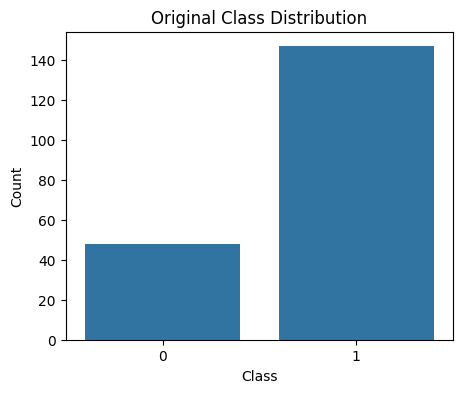

status
1    147
0     48
Name: count, dtype: int64


In [9]:
plt.figure(figsize=(5,4))

sns.countplot(x=y)

plt.title("Original Class Distribution")

plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

print(y.value_counts())

Train Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape: (146, 22)
Testing Shape : (49, 22)


Standardization

In [11]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling Completed")

Scaling Completed


Correlation Heatmap


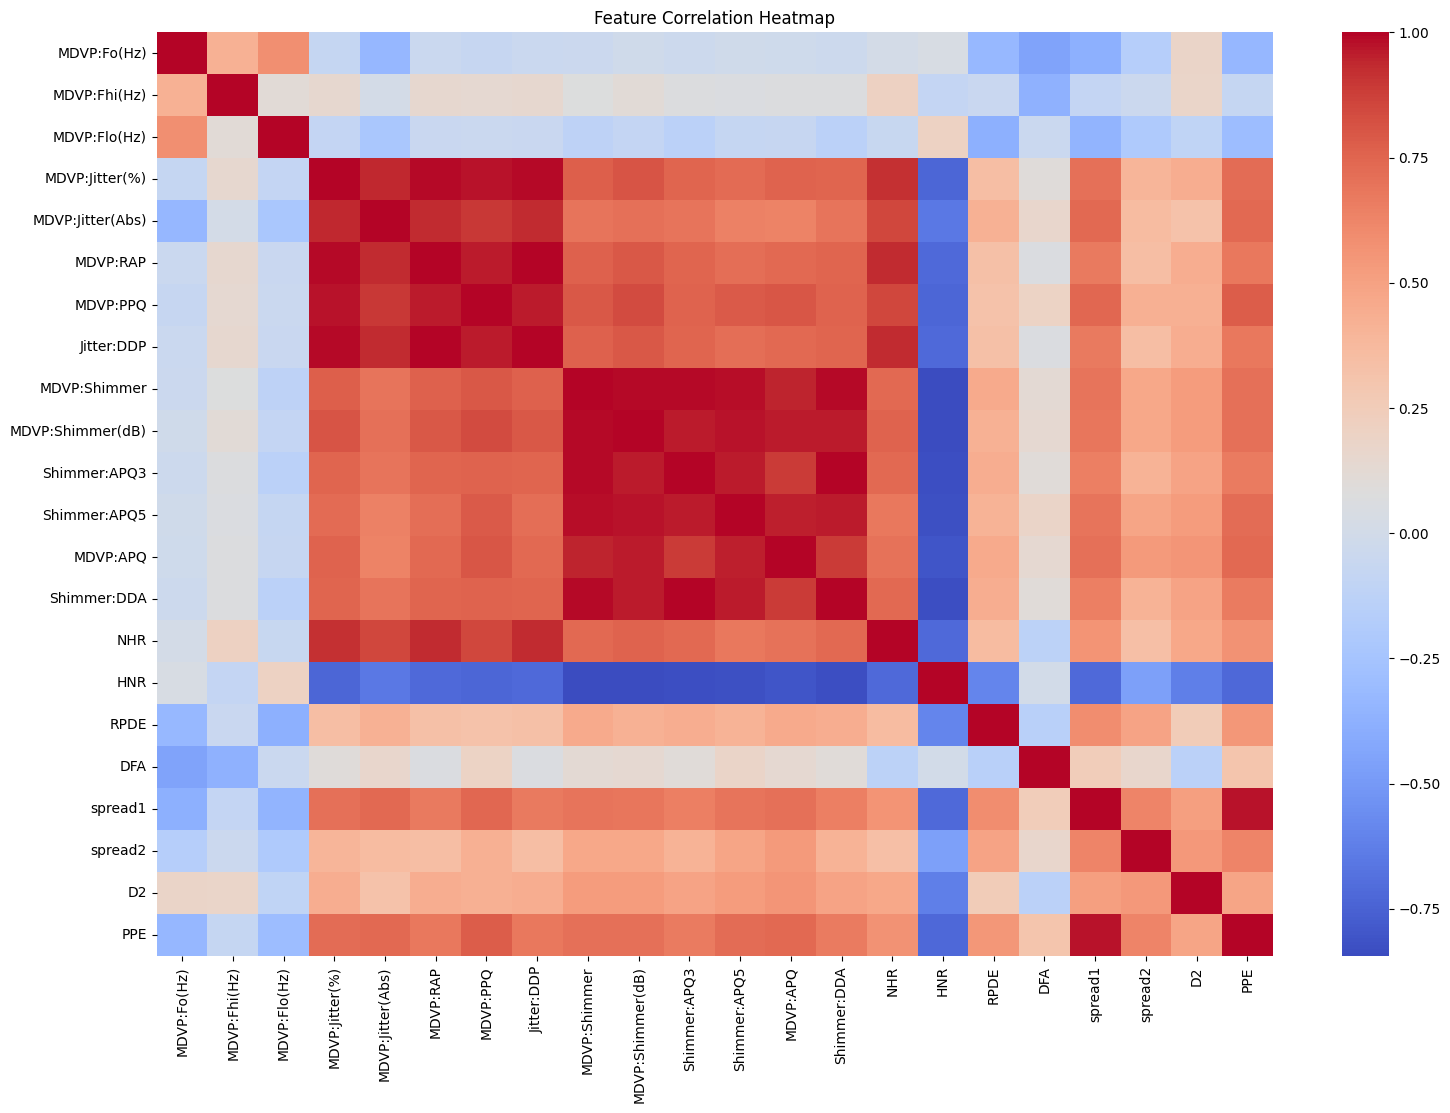

In [12]:
plt.figure(figsize=(18,12))

sns.heatmap(
    pd.DataFrame(X_train_scaled, columns=X.columns).corr(),
    cmap='coolwarm'
)

plt.title("Feature Correlation Heatmap")

plt.show()

BorderlineSMOTE

In [13]:
smote = BorderlineSMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter BorderlineSMOTE:")
print(pd.Series(y_train_smote).value_counts())

Before SMOTE:
status
1    110
0     36
Name: count, dtype: int64

After BorderlineSMOTE:
status
1    110
0    110
Name: count, dtype: int64


 Visualize Balanced Classes

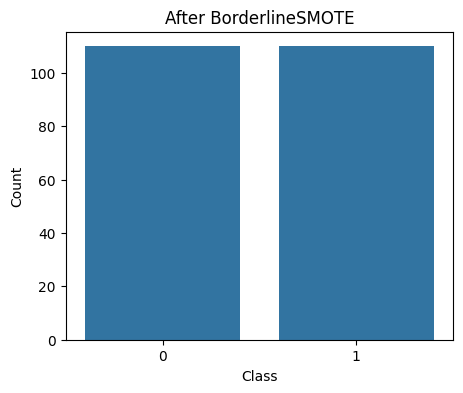

In [14]:
plt.figure(figsize=(5,4))

sns.countplot(x=y_train_smote)

plt.title("After BorderlineSMOTE")

plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

Baseline XGBoost Model

In [15]:
baseline_model = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

baseline_model.fit(X_train_smote, y_train_smote)

baseline_pred = baseline_model.predict(X_test_scaled)

baseline_prob = baseline_model.predict_proba(X_test_scaled)[:,1]

print(classification_report(y_test, baseline_pred))

print("Accuracy :", accuracy_score(y_test, baseline_pred))
print("F1 Score :", f1_score(y_test, baseline_pred))
print("ROC AUC  :", roc_auc_score(y_test, baseline_prob))

              precision    recall  f1-score   support

           0       0.85      0.92      0.88        12
           1       0.97      0.95      0.96        37

    accuracy                           0.94        49
   macro avg       0.91      0.93      0.92        49
weighted avg       0.94      0.94      0.94        49

Accuracy : 0.9387755102040817
F1 Score : 0.958904109589041
ROC AUC  : 0.9842342342342343


Feature Importance

In [16]:
importance = baseline_model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

             Feature  Importance
18           spread1    0.329354
0        MDVP:Fo(Hz)    0.090814
2       MDVP:Flo(Hz)    0.077849
8       MDVP:Shimmer    0.072327
1       MDVP:Fhi(Hz)    0.053007
19           spread2    0.052232
10      Shimmer:APQ3    0.044925
5           MDVP:RAP    0.044654
12          MDVP:APQ    0.042981
17               DFA    0.038394
3     MDVP:Jitter(%)    0.034444
11      Shimmer:APQ5    0.027130
20                D2    0.022721
14               NHR    0.018614
9   MDVP:Shimmer(dB)    0.015481
16              RPDE    0.014416
6           MDVP:PPQ    0.009537
4   MDVP:Jitter(Abs)    0.007127
15               HNR    0.003992
7         Jitter:DDP    0.000000
13       Shimmer:DDA    0.000000
21               PPE    0.000000


Top 10 Features

In [17]:
top_features = feature_importance.head(10)['Feature'].values

print("Top 10 Features:\n")

for feature in top_features:
    print(feature)

Top 10 Features:

spread1
MDVP:Fo(Hz)
MDVP:Flo(Hz)
MDVP:Shimmer
MDVP:Fhi(Hz)
spread2
Shimmer:APQ3
MDVP:RAP
MDVP:APQ
DFA


Select Top Features

In [18]:
X_train_top = pd.DataFrame(
    X_train_smote,
    columns=X.columns
)[top_features]

X_test_top = pd.DataFrame(
    X_test_scaled,
    columns=X.columns
)[top_features]

print(X_train_top.shape)
print(X_test_top.shape)

(220, 10)
(49, 10)


Bayesian Optimization

In [19]:
search_space = {
    'n_estimators': Integer(100, 500),
    'max_depth': Integer(3, 10),
    'learning_rate': Real(0.01, 0.3, prior='log-uniform'),
    'subsample': Real(0.5, 1.0),
    'colsample_bytree': Real(0.5, 1.0),
    'gamma': Real(0.0, 5.0)
}

xgb_model = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

bayes_search = BayesSearchCV(
    estimator=xgb_model,
    search_spaces=search_space,
    scoring='f1',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_iter=20,
    n_jobs=-1,
    random_state=42
)

bayes_search.fit(X_train_top, y_train_smote)

print("Best Parameters:\n")
print(bayes_search.best_params_)

Best Parameters:

OrderedDict({'colsample_bytree': 0.5, 'gamma': 0.0, 'learning_rate': 0.29999999999999993, 'max_depth': 10, 'n_estimators': 100, 'subsample': 1.0})


Final Optimized Model

In [20]:
final_model = bayes_search.best_estimator_

final_model.fit(X_train_top, y_train_smote)

final_prob = final_model.predict_proba(X_test_top)[:,1]

Threshold Optimization

In [21]:
thresholds = np.arange(0.30, 0.71, 0.01)

f1_scores = []

for threshold in thresholds:

    preds = (final_prob >= threshold).astype(int)

    score = f1_score(y_test, preds)

    f1_scores.append(score)

best_threshold = thresholds[np.argmax(f1_scores)]

print("Best Threshold:", best_threshold)

print("Best F1 Score :", max(f1_scores))

Best Threshold: 0.39000000000000007
Best F1 Score : 0.9722222222222222


Threshold vs F1 Plot

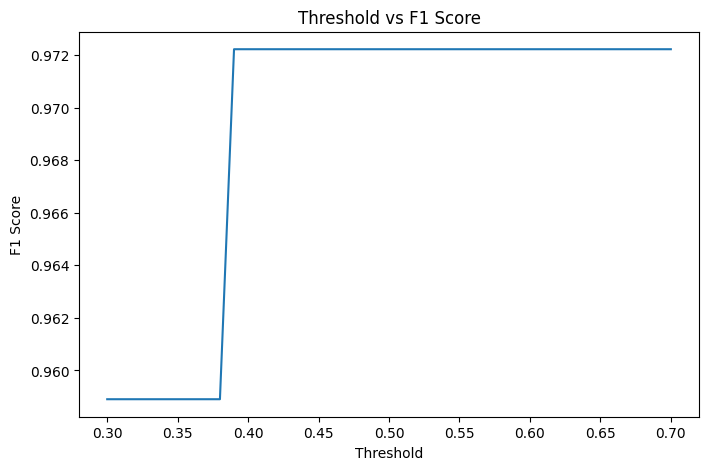

In [22]:
plt.figure(figsize=(8,5))

plt.plot(thresholds, f1_scores)

plt.xlabel("Threshold")
plt.ylabel("F1 Score")

plt.title("Threshold vs F1 Score")

plt.show()

Final Prediction Using Best Threshold

In [23]:
final_pred = (final_prob >= best_threshold).astype(int)

print(classification_report(y_test, final_pred))

print("Accuracy  :", accuracy_score(y_test, final_pred))
print("Precision :", precision_score(y_test, final_pred))
print("Recall    :", recall_score(y_test, final_pred))
print("F1 Score  :", f1_score(y_test, final_pred))
print("ROC AUC   :", roc_auc_score(y_test, final_prob))

              precision    recall  f1-score   support

           0       0.86      1.00      0.92        12
           1       1.00      0.95      0.97        37

    accuracy                           0.96        49
   macro avg       0.93      0.97      0.95        49
weighted avg       0.97      0.96      0.96        49

Accuracy  : 0.9591836734693877
Precision : 1.0
Recall    : 0.9459459459459459
F1 Score  : 0.9722222222222222
ROC AUC   : 0.9887387387387389


Confusion Matrix

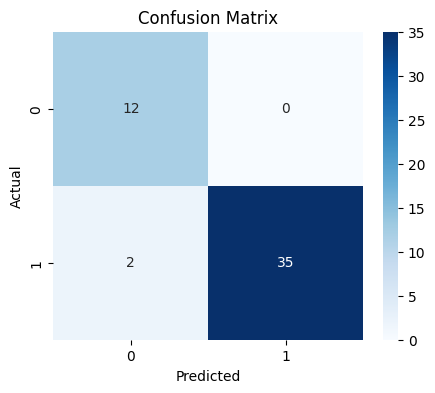

In [24]:
cm = confusion_matrix(y_test, final_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

ROC Curve

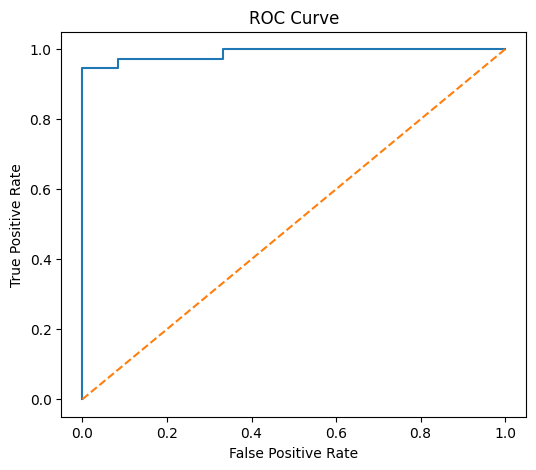

ROC AUC Score: 0.9887387387387389


In [25]:
fpr, tpr, thresholds = roc_curve(y_test, final_prob)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr)

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.show()

print("ROC AUC Score:", roc_auc_score(y_test, final_prob))

SHAP Explainability

In [26]:
explainer = shap.TreeExplainer(final_model)

shap_values = explainer.shap_values(X_test_top)

SHAP Summary Plot

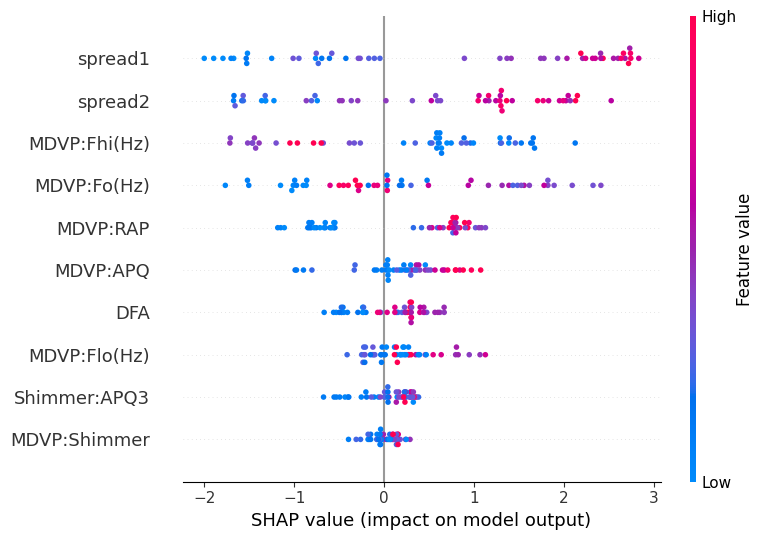

In [27]:
shap.summary_plot(
    shap_values,
    X_test_top
)

SHAP Force Plot (Single Sample)

In [28]:
shap.initjs()

sample_index = 0

shap.force_plot(
    explainer.expected_value,
    shap_values[sample_index],
    X_test_top.iloc[sample_index]
)

#Import Additional Models

In [29]:

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

SVM (RBF Kernel)

In [30]:
svm_model = SVC(
    kernel='rbf',
    probability=True,
    random_state=42
)

svm_model.fit(X_train_top, y_train_smote)

svm_pred = svm_model.predict(X_test_top)
svm_prob = svm_model.predict_proba(X_test_top)[:,1]

print("SVM Completed")

SVM Completed


 Random Forest

In [31]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train_top, y_train_smote)

rf_pred = rf_model.predict(X_test_top)
rf_prob = rf_model.predict_proba(X_test_top)[:,1]

print("Random Forest Completed")

Random Forest Completed


In [32]:
knn_model = KNeighborsClassifier(
    n_neighbors=5
)

knn_model.fit(X_train_top, y_train_smote)

knn_pred = knn_model.predict(X_test_top)
knn_prob = knn_model.predict_proba(X_test_top)[:,1]

print("KNN Completed")

KNN Completed


Logistic Regression

In [33]:
lr_model = LogisticRegression(
    max_iter=500,
    random_state=42
)

lr_model.fit(X_train_top, y_train_smote)

lr_pred = lr_model.predict(X_test_top)
lr_prob = lr_model.predict_proba(X_test_top)[:,1]

print("Logistic Regression Completed")

Logistic Regression Completed


Deep Neural Network (DNN)

In [34]:
dnn_model = Sequential([

    Dense(64, activation='relu', input_shape=(X_train_top.shape[1],)),
    Dropout(0.3),

    Dense(32, activation='relu'),
    Dropout(0.3),

    Dense(16, activation='relu'),

    Dense(1, activation='sigmoid')
])

dnn_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = dnn_model.fit(
    X_train_top,
    y_train_smote,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 70ms/step - accuracy: 0.6080 - loss: 0.6764 - val_accuracy: 0.0000e+00 - val_loss: 0.7948
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6250 - loss: 0.6496 - val_accuracy: 0.0000e+00 - val_loss: 0.7642
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6477 - loss: 0.6180 - val_accuracy: 0.2045 - val_loss: 0.7315
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6534 - loss: 0.5927 - val_accuracy: 0.7500 - val_loss: 0.6986
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7102 - loss: 0.5466 - val_accuracy: 0.7727 - val_loss: 0.6643
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7841 - loss: 0.5053 - val_accuracy: 0.7727 - val_loss: 0.6113
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7784 - loss: 0.4853 - val_accuracy: 0.7727 - val_loss: 0.5737
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7670 - loss: 0.4493 - val_accuracy: 0.7727 -

DNN Prediction

In [35]:

dnn_prob = dnn_model.predict(X_test_top)

dnn_prob = dnn_prob.flatten()

dnn_pred = (dnn_prob >= 0.5).astype(int)

print("DNN Completed")

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 435ms/step
DNN Completed


Optimized XGBoost Prediction

In [36]:
xgb_pred = final_pred
xgb_prob = final_prob

print("Optimized XGBoost Ready")

Optimized XGBoost Ready


Comparative Performance Table


In [37]:
results = pd.DataFrame({

    'Model': [
        'SVM (RBF Kernel)',
        'Random Forest',
        'K-Nearest Neighbors (KNN)',
        'Logistic Regression',
        'Deep Neural Network (DNN)',
        'Proposed XGBoost (Optimized)'
    ],

    'Accuracy (%)': [

        accuracy_score(y_test, svm_pred) * 100,
        accuracy_score(y_test, rf_pred) * 100,
        accuracy_score(y_test, knn_pred) * 100,
        accuracy_score(y_test, lr_pred) * 100,
        accuracy_score(y_test, dnn_pred) * 100,
        accuracy_score(y_test, xgb_pred) * 100
    ],

    'F1-Score (%)': [

        f1_score(y_test, svm_pred) * 100,
        f1_score(y_test, rf_pred) * 100,
        f1_score(y_test, knn_pred) * 100,
        f1_score(y_test, lr_pred) * 100,
        f1_score(y_test, dnn_pred) * 100,
        f1_score(y_test, xgb_pred) * 100
    ],

    'ROC-AUC (%)': [

        roc_auc_score(y_test, svm_prob) * 100,
        roc_auc_score(y_test, rf_prob) * 100,
        roc_auc_score(y_test, knn_prob) * 100,
        roc_auc_score(y_test, lr_prob) * 100,
        roc_auc_score(y_test, dnn_prob) * 100,
        roc_auc_score(y_test, xgb_prob) * 100
    ]
})

results = results.round(2)

print(results)

                          Model  Accuracy (%)  F1-Score (%)  ROC-AUC (%)
0              SVM (RBF Kernel)         89.80         92.75        96.40
1                 Random Forest         97.96         98.63        98.99
2     K-Nearest Neighbors (KNN)         83.67         88.24        93.92
3           Logistic Regression         79.59         84.85        93.47
4     Deep Neural Network (DNN)         87.76         91.67        96.62
5  Proposed XGBoost (Optimized)         95.92         97.22        98.87


Comparative Bar Chart (Accuracy)

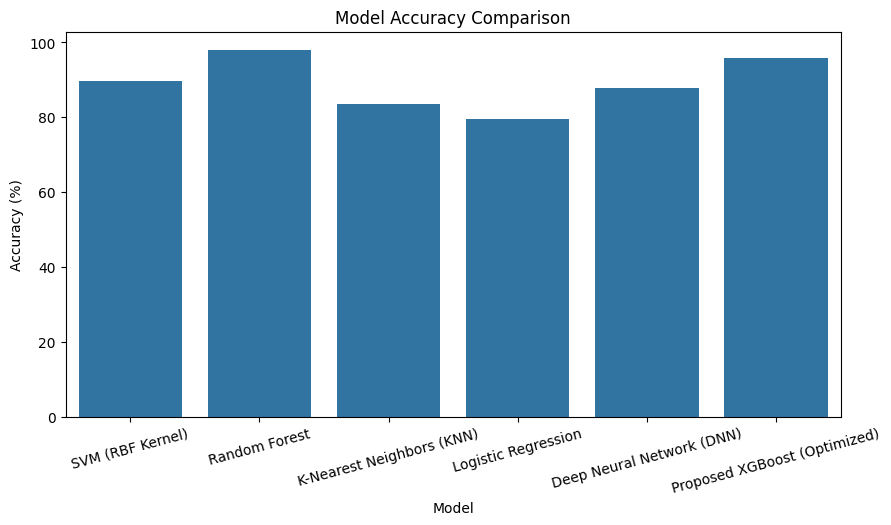

In [38]:
plt.figure(figsize=(10,5))

sns.barplot(
    x='Model',
    y='Accuracy (%)',
    data=results
)

plt.xticks(rotation=15)

plt.title("Model Accuracy Comparison")

plt.show()

Comparative Bar Chart (F1 Score)

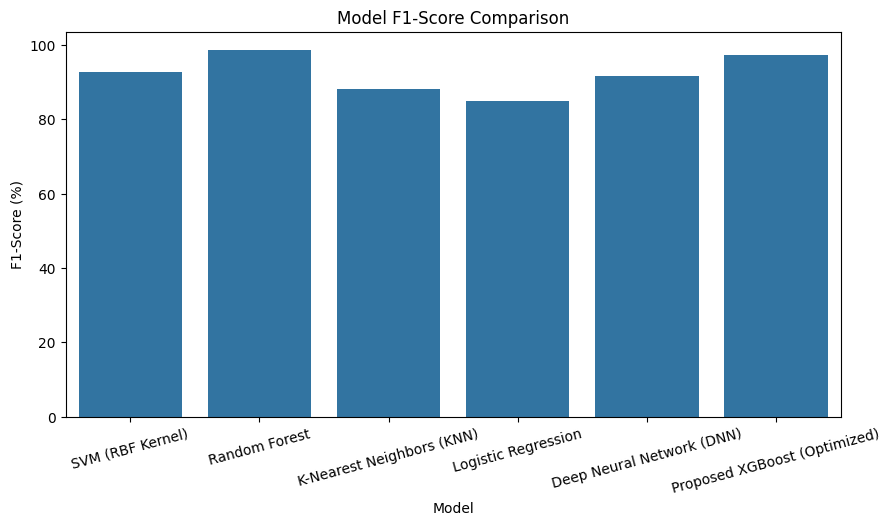

In [39]:
plt.figure(figsize=(10,5))

sns.barplot(
    x='Model',
    y='F1-Score (%)',
    data=results
)

plt.xticks(rotation=15)

plt.title("Model F1-Score Comparison")

plt.show()

Comparative ROC Curve

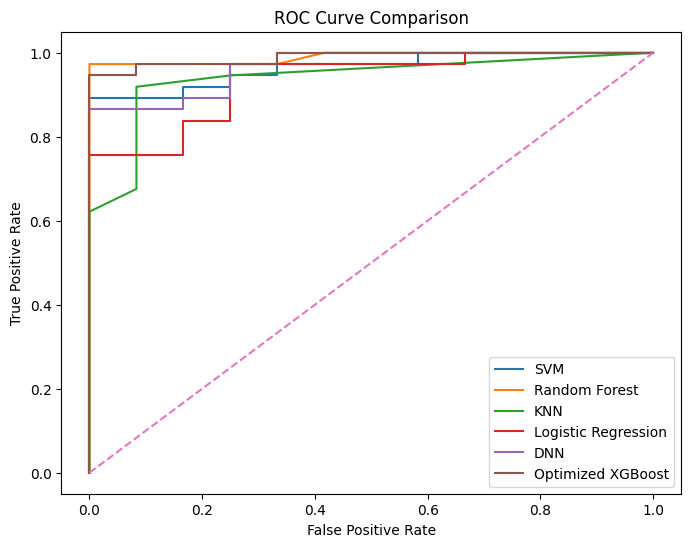

In [40]:
plt.figure(figsize=(8,6))

# SVM
fpr, tpr, _ = roc_curve(y_test, svm_prob)
plt.plot(fpr, tpr, label='SVM')

# RF
fpr, tpr, _ = roc_curve(y_test, rf_prob)
plt.plot(fpr, tpr, label='Random Forest')

# KNN
fpr, tpr, _ = roc_curve(y_test, knn_prob)
plt.plot(fpr, tpr, label='KNN')

# LR
fpr, tpr, _ = roc_curve(y_test, lr_prob)
plt.plot(fpr, tpr, label='Logistic Regression')

# DNN
fpr, tpr, _ = roc_curve(y_test, dnn_prob)
plt.plot(fpr, tpr, label='DNN')

# XGBoost
fpr, tpr, _ = roc_curve(y_test, xgb_prob)
plt.plot(fpr, tpr, label='Optimized XGBoost')

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

Save Results Table

In [42]:
results.to_csv('model_comparison_results.csv', index=False)

print("Results Saved Successfully")

Results Saved Successfully
